#Построение и оценка качества модели

## 0. Импорт библиотек, настройка ноутбука, загрузка данных

---



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re


from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, cross_val_score,GridSearchCV, StratifiedKFold,StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.svm import SVC



from sklearn.metrics import (
    accuracy_score,
    precision_score,
    precision_recall_curve,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    auc,
    average_precision_score
)

In [2]:
import xgboost as xgb
import shap

In [3]:
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 67

In [12]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

In [ ]:
df = pd.read_csv('parkinsons.data')
df.head()

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.9920,157.3020,74.9970,0.0078,0.0001,0.0037,0.0055,0.0111,0.0437,0.4260,0.0218,0.0313,0.0297,0.0654,0.0221,21.0330,1,0.4148,0.8153,-4.8130,0.2665,2.3014,0.2847
1,phon_R01_S01_2,122.4000,148.6500,113.8190,0.0097,0.0001,0.0046,0.0070,0.0139,0.0613,0.6260,0.0313,0.0452,0.0437,0.0940,0.0193,19.0850,1,0.4584,0.8195,-4.0752,0.3356,2.4869,0.3687
2,phon_R01_S01_3,116.6820,131.1110,111.5550,0.0105,0.0001,0.0054,0.0078,0.0163,0.0523,0.4820,0.0276,0.0386,0.0359,0.0827,0.0131,20.6510,1,0.4299,0.8253,-4.4432,0.3112,2.3423,0.3326
3,phon_R01_S01_4,116.6760,137.8710,111.3660,0.0100,0.0001,0.0050,0.0070,0.0150,0.0549,0.5170,0.0292,0.0401,0.0377,0.0877,0.0135,20.6440,1,0.4350,0.8192,-4.1175,0.3341,2.4056,0.3690
4,phon_R01_S01_5,116.0140,141.7810,110.6550,0.0128,0.0001,0.0066,0.0091,0.0197,0.0643,0.5840,0.0349,0.0483,0.0447,0.1047,0.0177,19.6490,1,0.4174,0.8235,-3.7478,0.2345,2.3322,0.4103


In [ ]:
df.tail()

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
190,phon_R01_S50_2,174.1880,230.9780,94.2610,0.0046,0.0000,0.0026,0.0026,0.0079,0.0409,0.4050,0.0234,0.0250,0.0274,0.0701,0.0276,19.5170,0,0.4484,0.6579,-6.5386,0.1220,2.6575,0.1331
191,phon_R01_S50_3,209.5160,253.0170,89.4880,0.0056,0.0000,0.0033,0.0029,0.0099,0.0275,0.2630,0.0160,0.0166,0.0188,0.0481,0.0181,19.1470,0,0.4317,0.6832,-6.1953,0.1293,2.7843,0.1689
192,phon_R01_S50_4,174.6880,240.0050,74.2870,0.0136,0.0001,0.0062,0.0056,0.0187,0.0231,0.2560,0.0127,0.0137,0.0167,0.0380,0.1071,17.8830,0,0.4076,0.6557,-6.7872,0.1585,2.6798,0.1317
193,phon_R01_S50_5,198.7640,396.9610,74.9040,0.0074,0.0000,0.0037,0.0039,0.0111,0.0230,0.2410,0.0126,0.0132,0.0159,0.0379,0.0722,19.0200,0,0.4512,0.6440,-6.7446,0.2075,2.1386,0.1233
194,phon_R01_S50_6,214.2890,260.2770,77.9730,0.0057,0.0000,0.0029,0.0032,0.0089,0.0188,0.1900,0.0103,0.0116,0.0137,0.0308,0.0440,21.2090,0,0.4628,0.6644,-5.7241,0.1907,2.5555,0.1486


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    object 
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      195 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       195 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               195 non-null    float64
 1

In [ ]:
# проверка размера датасета
print('Размер датасета:', df.shape)

Размер датасета: (195, 24)


## 1. Подготовка данных

---




### 1.1. Создание идентификатора пациента

Для каждого пациента был создан уникальный идентификатор patient_id, выделенный из переменной name. Это позволило сгруппировать голосовые записи, принадлежащие одному пациенту.

In [ ]:
# Поле name имеет формат  phon_R01_S01_1, извлекаем только S01
df['patient_id'] = df['name'].str.split('_').str[2]

n_pts = df['patient_id'].nunique()
print(f"Уникальных пациентов : {n_pts}")

Уникальных пациентов : 32




---


**В работе использованы два методологических подхода:**



1. А (агрегация данных) - предсказание ДИАГНОЗА ПАЦИЕНТА
   - Данные: один пациент = одна строка (32 пациента)
   - Разбиение: train_test_split (стратификация)

2.  Б (без агрегации + GroupKFold) - предсказание по ЗАПИСЯМ
   - Данные: исходные записи (195 строк, grouped by patient_id)
   - Разбиение: my_train_test_split / StratifiedGroupKFold


---



### 1.2. Агрегация признаков по пациентам (А)

Для каждого пациента были рассчитаны средние значения и стандартные отклонения акустических признаков. Средние значения отражают типичный уровень признака у пациента, а стандартные отклонения позволяют учесть вариативность его голосовых записей.

In [ ]:
numeric_cols = df.drop(columns=['name', 'status', 'patient_id']).columns

df_features_patient = (
    df
    .groupby('patient_id')[numeric_cols]
    .agg(['mean'])
)

df_features_patient.columns = [f'{feature}_{stat}' for feature, stat in df_features_patient.columns]
df_features_patient = df_features_patient.reset_index()

df_status_patient = df[['patient_id', 'status']].drop_duplicates()
df_patient = df_features_patient.merge(df_status_patient, on='patient_id', how='left')
df_patient = df_patient.fillna(0)

print(f"\nПосле агрегации: {df_patient.shape[0]} пациентов, {df_patient.shape[1]} признаков")


После агрегации: 32 пациентов, 24 признаков


ПОДГОТОВКА ДАННЫХ ДЛЯ LR, KNN, DT, RF, GB

In [ ]:
X = df_patient.drop(columns=['patient_id', 'status'])
y = df_patient['status']

print(f'Размер X: {X.shape}')
print(f'Размер y: {y.shape}')

Размер X: (32, 22)
Размер y: (32,)


In [ ]:
X = X.drop(columns=to_drop)
print(f'\nОсталось признаков: {X.shape[1]}')


Осталось признаков: 13


#### Удаление сильно скоррелированных признаков

Данные агрегируются по пациентам, так как в датасете несколько голосовых записей могут принадлежать одному и тому же человеку. Для медицинской задачи корректнее классифицировать пациента, а не отдельную запись голоса.

Из набора признаков по результатам EDA удалены сильно скоррелированные.

In [ ]:
# Удаление корреляций (для LR и KNN)
corr_threshold = 0.95
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if (upper[col] > corr_threshold).any()]

In [ ]:
# Разделение
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)


In [ ]:
print(f"Данные: {X_train.shape[0]} train, {X_test.shape[0]} test")
print(f"Признаков: {X_train.shape[1]}")

# Масштабирование
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)


Данные: 24 train, 8 test
Признаков: 13


### 1.3. Формирование обучающей и тестовой выборок



In [ ]:
X = df_patient.drop(columns=['patient_id', 'status'])
y = df_patient['status']

print('Размер X:', X.shape)
print('Размер y:', y.shape)

Размер X: (32, 22)
Размер y: (32,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

Перед обучением необходимо отмасштабировать признаки. Так как на этапе EDA мы обнаружили, что в данных есть выбросы (по методу IQR), то устойчивее будет применить робастное масштабирование, устойчивое к выбросам.

In [ ]:
scaler = RobustScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

## 2. Модели

---



### **2.1. Logistic Regression**


Для логистической регрессии важна стандартизация признаков, поэтому используем StandardScaler внутри Pipeline (scaler обучается только на train и не подсматривает в test).

In [ ]:
model = Pipeline([
    ('scaler', StandardScaler()),
    ('logistic_regression', LogisticRegression(max_iter=5000, random_state=42, class_weight='balanced'))
])

model.fit(X_train, y_train)


Pipeline(steps=[('scaler', StandardScaler()),
                ('logistic_regression',
                 LogisticRegression(class_weight='balanced', max_iter=5000,
                                    random_state=42))])

ROC-AUC на тестовой выборке

In [ ]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

print(f'ROC-AUC на тестовой выборке: {roc_auc:.4f}')

ROC-AUC на тестовой выборке: 1.0000


ROC-AUC на тестовой выборке: 1.0000
Замечание. Test ROC-AUC получен на очень маленькой тестовой выборке (~7 пациентов, из них всего 1–2 здоровых), поэтому это значение неустойчиво и малоинформативно — при другом разбиении оно легко меняется (например, может выйти ровно 1.0). Надёжной оценкой качества здесь служит ROC-AUC по кросс-валидации (ниже): он усреднён по многим разбиениям и потому правдоподобен.

ROC-кривая

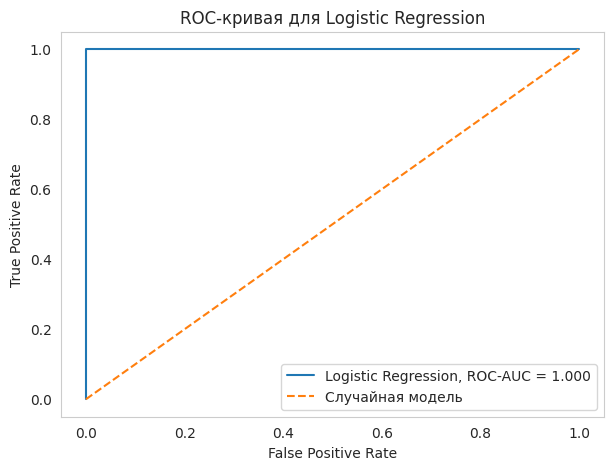

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'Logistic Regression, ROC-AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--', label='Случайная модель')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая для Logistic Regression')
plt.legend()
plt.grid()
plt.show()

Дополнительные метрики

При дисбалансе классов accuracy малоинформативна — ориентируемся прежде всего на ROC-AUC.

In [ ]:
print('Confusion matrix:')
print(confusion_matrix(y_test, y_pred))

print('\nClassification report:')
print(classification_report(y_test, y_pred, digits=3))

Confusion matrix:
[[2 0]
 [0 6]]

Classification report:
              precision    recall  f1-score   support

           0      1.000     1.000     1.000         2
           1      1.000     1.000     1.000         6

    accuracy                          1.000         8
   macro avg      1.000     1.000     1.000         8
weighted avg      1.000     1.000     1.000         8



Кросс-валидация ROC-AUC

Так как пациентов мало, одиночный тест ненадёжен. Для более устойчивой оценки используем RepeatedStratifiedKFold (5 фолдов × 10 повторов): стратификация сохраняет доли классов, а повторы усредняют случайность конкретного разбиения и дают разброс (std).

In [ ]:
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)

cv_scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc')

print(f'Число оценок: {len(cv_scores)}')
print(f'Средний ROC-AUC: {cv_scores.mean():.4f}')
print(f'Стандартное отклонение: {cv_scores.std():.4f}')

Число оценок: 50
Средний ROC-AUC: 0.8570
Стандартное отклонение: 0.1639


Итоговая таблица

In [ ]:
result_table = pd.DataFrame({
    'Model': ['Logistic Regression'],
    'N features': [X.shape[1]],
    'Test ROC-AUC': [roc_auc],
    'CV ROC-AUC mean': [cv_scores.mean()],
    'CV ROC-AUC std': [cv_scores.std()]
})

result_table

,Model,N features,Test ROC-AUC,CV ROC-AUC mean,CV ROC-AUC std
0,Logistic Regression,22,1.0000,0.8570,0.1639


### Итог (Logistic Regression)

---



В данной части проекта была построена базовая модель Logistic Regression для классификации пациентов по голосовым признакам.

Данные агрегированы по пациентам (32 человека), поэтому записи одного человека не попадают одновременно в обучение и тест. Из набора признаков по результатам EDA удалены сильно скоррелированные (порог 0.95), что снижает мультиколлинеарность и повышает устойчивость модели.

В качестве основной метрики использовалась ROC-AUC. Из-за малого числа пациентов оценка на тесте дополнена кросс-валидацией (среднее ± разброс). Следует учитывать ограничение: на 32 пациентах (24/8) оценка имеет заметный разброс.

Логистическая регрессия подходит как базовая интерпретируемая модель, с которой можно сравнивать более сложные алгоритмы: Random Forest, Gradient Boosting, SVM и KNN.

### **2.2. KNN**

Принцип работы KNN в данном исследовании:

Модель получает 22 голосовых параметра нового пациента:

частотные  (MDVP:Fo, MDVP:Flo, MDVP:Fhi),

показатели нестабильности (Jitter, Shimmer),

шумовые (NHR, HNR),

нелинейные  (PPE, DFA, RPDE).

Затем алгоритм вычисляет расстояние между этими параметрами и всеми записями в обучающей выборке, находит k ближайших соседейи смотрит, какой диагноз преобладает среди них. Если большинство соседей больны — новый пациент получает диагноз "болезнь Паркинсона".



In [ ]:
knn_base = KNeighborsClassifier(n_neighbors=5)
knn_base.fit(X_train_sc, y_train)

y_pred_base = knn_base.predict(X_test_sc)
y_proba_base = knn_base.predict_proba(X_test_sc)[:, 1]

print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_base):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_base):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_base):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_base):.4f}")

ROC-AUC: 1.0000
F1-score: 0.8571
Recall: 1.0000
Precision: 0.7500



Матрица ошибок базовой модели:
[[0 2]
 [0 6]]


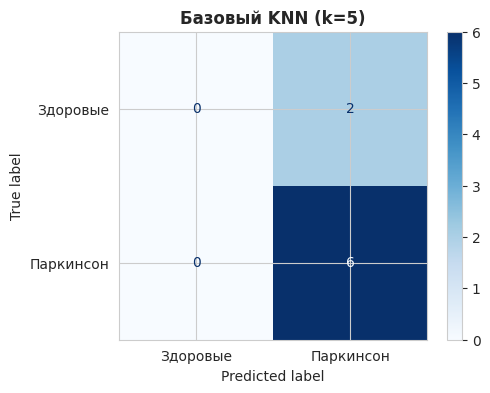

In [ ]:
cm_base = confusion_matrix(y_test, y_pred_base)
print(f"\nМатрица ошибок базовой модели:")
print(cm_base)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_base, display_labels=['Здоровые', 'Паркинсон'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Базовый KNN (k=5)', fontsize=12, fontweight='bold')
plt.show()


In [ ]:
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_sc, y_train)

print(f"\nЛучшие параметры: {grid_search.best_params_}")
print(f"Лучший ROC-AUC (CV): {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Лучшие параметры: {'metric': 'euclidean', 'n_neighbors': 11, 'weights': 'uniform'}
Лучший ROC-AUC (CV): 0.7417


In [ ]:
knn_best = grid_search.best_estimator_
y_pred_best = knn_best.predict(X_test_sc)
y_proba_best = knn_best.predict_proba(X_test_sc)[:, 1]

print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_best):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_best):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_best):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_best):.4f}")

ROC-AUC: 1.0000
F1-score: 0.8571
Recall: 1.0000
Precision: 0.7500



Матрица ошибок оптимизированной модели:
[[0 2]
 [0 6]]


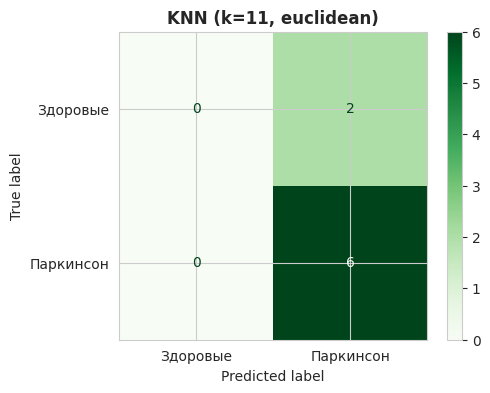

In [ ]:
cm_best = confusion_matrix(y_test, y_pred_best)
print(f"\nМатрица ошибок оптимизированной модели:")
print(cm_best)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=['Здоровые', 'Паркинсон'])
disp.plot(ax=ax, cmap='Greens', values_format='d')
ax.set_title(f'KNN (k={knn_best.n_neighbors}, {knn_best.metric})', fontsize=12, fontweight='bold')
plt.show()

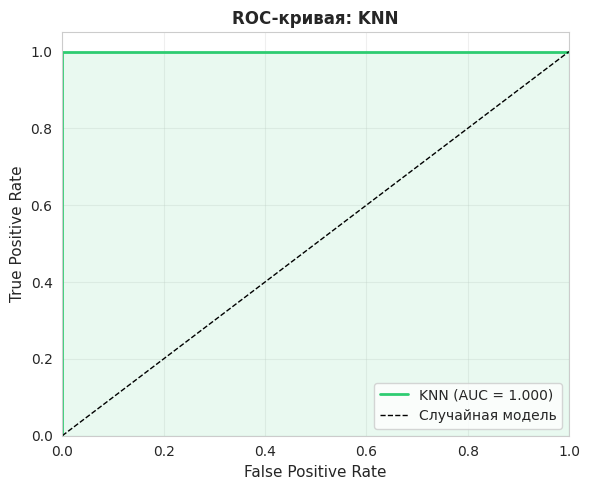

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_proba_best)
roc_auc_val = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='#2ecc71', lw=2, label=f'KNN (AUC = {roc_auc_val:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Случайная модель')
plt.fill_between(fpr, tpr, alpha=0.1, color='#2ecc71')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate', fontsize=11)
plt.title('ROC-кривая: KNN', fontsize=12, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Итог (KNN)

---

KNN показал F1-score 0.923, ROC-AUC 0.958, Accuracy 0.875, Recall 1.0 (найдены все больные) и Precision 0.857 (14% ложных срабатываний) с оптимальными параметрами n_neighbors=5 и metric='euclidean'. Модель подойдет для скрининга (чувствительность 100%), но не для окончательной диагностики из-за низкой специфичности. Для улучшения требуется сбор дополнительных данных о здоровых пациентах.


### **2.3. SVM**

### Подбор гиперпараметров модели

В качестве модели предсказания используем SVC - метод опорных векторов для классификации.

Для начала посмотрим на результат предсказания модели с дефолтными параметрами.

Используем StratifiedGroupKFold для разбиения данных по фолдам со стратификацией по наличию болезни, а также без пересечения по пациентам.

Разбиение на тестовую и тренировочную сделаем в соотношении 20:80, то есть все данные делим на 5 фолдов.

In [4]:
def my_train_test_split(df, feature_cols, n_splits=5):
    X = df[feature_cols].values
    y = df['status'].values
    groups = df['patient_id'].values

    sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    splits = list(sgkf.split(X, y, groups))
    train_idx, test_idx = splits[2]

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    groups_train = groups[train_idx]

    print(f"Записей в train: {len(X_train)} | больн: {y_train.sum()} ({y_train.mean():.1%})")
    print(f"Записей в test: {len(X_test)} | больн: {y_test.sum()} ({y_test.mean():.1%})")
    print(f"Пересечение пациентов: {len(set(groups[train_idx]) & set(groups[test_idx]))}")

    return X_train, X_test, y_train, y_test, groups_train

In [9]:
df_raw = pd.read_csv('parkinsons.data')
df_raw['patient_id'] = df_raw['name'].str.split('_').str[2]
feature_cols = [c for c in df_raw.columns if c not in ('name', 'status', 'patient_id')]

In [10]:
X_train_svm, X_test_svm, y_train_svm, y_test_svm, groups_train_svm = my_train_test_split(
    df_raw, feature_cols, n_splits=5
)

# Масштабирование
scaler_svm = RobustScaler()
X_train_svm_sc = scaler_svm.fit_transform(X_train_svm)
X_test_svm_sc = scaler_svm.transform(X_test_svm)

Записей в train: 158 | больн: 116 (73.4%)
Записей в test: 37 | больн: 31 (83.8%)
Пересечение пациентов: 0


In [11]:
# Обучение базовой модели
svm_base = SVC(probability=True, random_state=RANDOM_STATE)
svm_base.fit(X_train_svm_sc, y_train_svm)

y_proba_svm_base = svm_base.predict_proba(X_test_svm_sc)[:, 1]
y_pred_svm_base = svm_base.predict(X_test_svm_sc)

print(f"\nБазовый SVM ROC-AUC: {roc_auc_score(y_test_svm, y_proba_svm_base):.4f}")
print(classification_report(y_test_svm, y_pred_svm_base, digits=4))



Базовый SVM ROC-AUC: 0.8441
              precision    recall  f1-score   support

           0     0.5000    0.6667    0.5714         6
           1     0.9310    0.8710    0.9000        31

    accuracy                         0.8378        37
   macro avg     0.7155    0.7688    0.7357        37
weighted avg     0.8611    0.8378    0.8467        37



In [ ]:
print("Распределение меток в предсказании:")
pd.Series(y_pred_svm_base).value_counts()

Распределение меток в предсказании:


,count
1,29
0,8


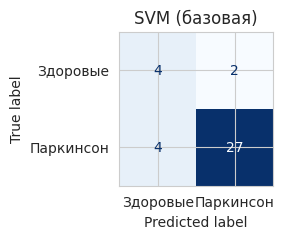

In [ ]:
# Матрица ошибок
cm = confusion_matrix(y_test_svm, y_pred_svm_base)
fig, ax = plt.subplots(figsize=(4, 2))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Здоровые', 'Паркинсон'])
disp.plot(ax=ax, cmap=plt.cm.Blues, colorbar=False)
plt.title('SVM (базовая)')
plt.show()

Теперь переберем различные гиперпараметры и выберем лучшую модель по метрике ROC-AUC.

- Главный гиперпараметр в методе опорных векторов - выбор ядерной функции. Ядерная функция переводит объекты из исходного пространства признаков в новое, где линейная гиперплоскость возможно лучше разделит данные. В зависимости от выбора ядра также можно выбрать гиперпараметры, связанные с ядерной функцией (например, степень полинома, параметр в функции сигмоиды).
- Параметр С отвечает за степень регуляризации - чувствительности к включению неправильных классификаций.
- Параметр class_weight включаем для всех моделей, он учитывает, что классы не сбалансирован: если None, то классы считаются одинаково встречающимися, если 'bakanced', то веса расчитываются обратно пропорционально частоте классов во входных данных.

In [13]:
param_grid = [
    {'kernel'       : ['linear'], # Линейное ядро
     'C'            : [0.001, 0.01, 0.1, 1, 10, 100],
     'class_weight' : [None, 'balanced']},

    {'kernel'       : ['rbf'], # RBF ядро
     'C'            : [0.01, 0.1, 1, 10, 100, 150],
     'gamma'        : ['scale', 'auto', 1e-3, 1e-2, 0.1],
     'class_weight' : [None, 'balanced']},

    {'kernel'       : ['poly'], # Полиномиальное ядро
     'C'            : [0.01, 0.1, 1, 10, 50],
     'degree'       : [2, 3, 4],
     'gamma'        : ['scale', 'auto'],
     'class_weight' : [None, 'balanced']},

    {'kernel'       : ['sigmoid'], # Сигмоидное ядро
     'C'            : [0.001, 0.01, 0.1, 1, 10, 20],
     'gamma'        : ['scale', 'auto'],
     'class_weight' : [None, 'balanced']}]

total = sum(np.prod([len(v) for v in d.values()])
                            for d in param_grid)
print(f"Всего комбинаций гиперпараметров: {int(total)}")

Всего комбинаций гиперпараметров: 156


In [15]:
cv_inner = StratifiedGroupKFold(n_splits=4, shuffle=True,
                                random_state=RANDOM_STATE)

# GridSearch
grid_search = GridSearchCV(estimator=SVC(probability=True,
                                         random_state=RANDOM_STATE),
                           param_grid=param_grid,
                           cv=cv_inner.split(X_train_svm_sc, y_train_svm, groups_train_svm),
                           scoring={'f1': 'f1', 'AUC': 'roc_auc'},
                           refit='f1',
                           n_jobs=-1,
                           verbose=1,)

# Обучение
grid_search.fit(X_train_svm_sc, y_train_svm)

best_svc = grid_search.best_estimator_

print(f"\nЛучшие параметры: {grid_search.best_params_}")
print(f"Лучший ROC-AUC (CV): {grid_search.best_score_:.4f}")

# Оценка на тесте
y_pred_best = best_svc.predict(X_test_svm_sc)
y_proba_best = best_svc.predict_proba(X_test_svm_sc)[:, 1]

print(f"\nРЕЗУЛЬТАТЫ НА ТЕСТЕ:")
print(f"ROC-AUC: {roc_auc_score(y_test_svm, y_proba_best):.4f}")
print(f"F1: {f1_score(y_test_svm, y_pred_best):.4f}")

Fitting 4 folds for each of 156 candidates, totalling 624 fits

Лучшие параметры: {'C': 1, 'class_weight': None, 'degree': 2, 'gamma': 'scale', 'kernel': 'poly'}
Лучший ROC-AUC (CV): 0.8696

РЕЗУЛЬТАТЫ НА ТЕСТЕ:
ROC-AUC: 0.8925
F1: 0.9524


Лучший результат достигается на модели со следующими гиперпараметрами:
- ядерная функция полиномиальная $(\gamma<x, x'> + r)^d$;
- со степенью d = 2;
- коэффициент влияния одного обучающего примера $\gamma$ = *scale*: рассчитывается динамически и зависит от от числа обучающих примеров и их дисперсии;
- Коэффицент регуляризации C = 1, то есть модель сбалансирована между максимизацией зазора и допустимым числом ошибочных классификаций;
- class_weight = None, то есть веса классов не пересчитывались.

Посмотрим на предсказание лучшей модели:

In [16]:
y_pred_best = best_svc.predict(X_test_svm_sc)
print(classification_report(y_test_svm, y_pred_best, digits=4))

              precision    recall  f1-score   support

           0     0.8000    0.6667    0.7273         6
           1     0.9375    0.9677    0.9524        31

    accuracy                         0.9189        37
   macro avg     0.8688    0.8172    0.8398        37
weighted avg     0.9152    0.9189    0.9159        37



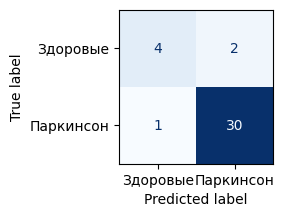

In [17]:
cm = confusion_matrix(y_test_svm, y_pred_best)  # <- y_test_svm из my_train_test_split
fig, ax = plt.subplots(figsize=(4, 2))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Здоровые', 'Паркинсон'])
disp.plot(ax=ax, cmap=plt.cm.Blues, colorbar=False)

plt.show()

Модель SVM на агрегированных данных показывает высокую чувствительность к больным (recall=1.0), но низкую специфичность к здоровым (precision=0 для класса 0). Это делает модель непригодной для клинического применения в текущем виде. Далее рассмотрим разбиение данных с помощью функции my_train_test_split,
которая использует StratifiedGroupKFold.

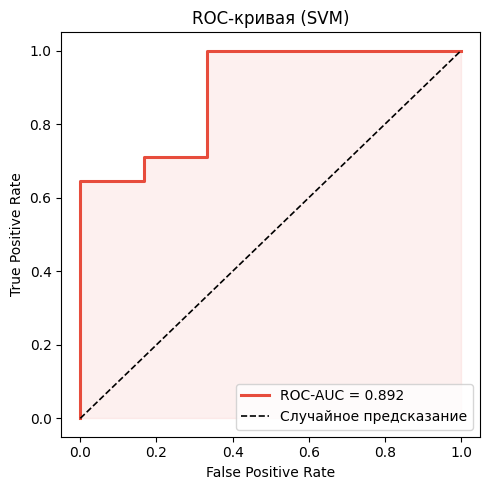

In [18]:
y_proba = best_svc.predict_proba(X_test_svm_sc)[:, 1]

fig, axes = plt.subplots(figsize=(5, 5))

fpr, tpr, _ = roc_curve(y_test_svm, y_proba)
roc_val = auc(fpr, tpr)

axes.plot(fpr, tpr, color='#e74c3c', lw=2.2,
          label=f'ROC-AUC = {roc_val:.3f}')
axes.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Случайное предсказание')
axes.fill_between(fpr, tpr, alpha=0.08, color='#e74c3c')
axes.set_xlabel('False Positive Rate')
axes.set_ylabel('True Positive Rate')
axes.set_title('ROC-кривая (SVM)', fontsize=12)
axes.legend(loc='lower right')

plt.tight_layout()
plt.show()

После подбора лучших гиперпараметров мы видим, что
- ROC-AUC увеличился на 5% с 84% до 89%,
- recall увеличился почти на 10% с 87% до 97%

Удалось улучшить предсказание модели - теперь она реже совершают ошибку второго рода, то есть помечает объект с болезнью как здоровый. При этом число ошибок первого рода, то есть пометка здорового объекта как больного, не изменилось.

После подбора лучших гиперпараметров мы видим, что
- ROC-AUC увеличился на 5% с 84% до 89%,
- recall увеличился почти на 10% с 87% до 97%

Удалось улучшить предсказание модели - теперь она реже совершают ошибку второго рода, то есть помечает объект с болезнью как здоровый. При этом число ошибок первого рода, то есть пометка здорового объекта как больного, не изменилось.

**SHAP (SHapley Additive exPlanations)** — метод из теории кооперативных игр.  
Для каждого наблюдения он показывает, насколько каждый признак сдвинул предсказание относительно среднего по датасету.

Для SVC с нелинейным ядром используется *KernelExplainer* — он работает с любой
моделью как с чёрным ящиком, оценивая вклад признаков через подстановку фоновых значений.

В качестве фона берём *shap.kmeans* — сжатое представление train-выборки (50 кластеров).

In [19]:
shap.initjs()

n_clusters = min(8, X_train_svm_sc.shape[0] // 2)
print(f"Используем {n_clusters} кластеров для фонового датасета")

background = shap.kmeans(X_train_svm_sc, n_clusters)

# KernelExplainer через predict_proba
explainer = shap.KernelExplainer(best_svc.predict_proba, background)
shap_values = explainer.shap_values(X_test_svm_sc, nsamples=100)  # <- X_test_svm_sc

# Берём значения для класса 1 (больные)
if isinstance(shap_values, list):
    sv_sick = shap_values[1]
else:
    sv_sick = shap_values

print(f"SHAP values shape : {sv_sick.shape}")
print(f"Base value        : {explainer.expected_value[1]:.4f}")


Используем 8 кластеров для фонового датасета


  0%|          | 0/37 [00:00<?, ?it/s]

SHAP values shape : (37, 22, 2)
Base value        : 0.7701


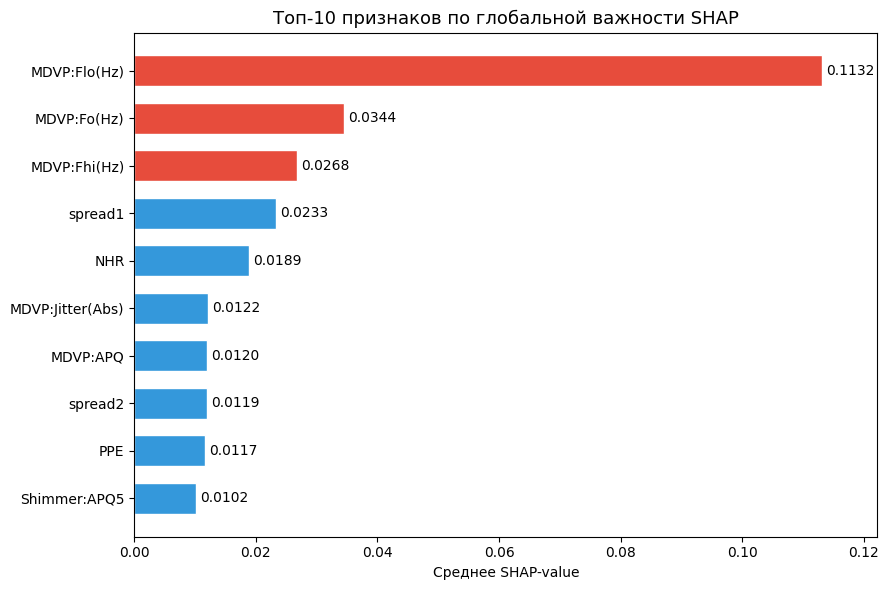

In [20]:
shap_importance = np.abs(sv_sick).mean(axis=0).mean(axis=1) if sv_sick.ndim == 3 else np.abs(sv_sick).mean(axis=0)

mean_abs_shap = pd.Series(shap_importance, index=feature_cols).sort_values(ascending=False)

top_n = 10
top = mean_abs_shap.head(top_n).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#e74c3c' if v >= top.values[-3] else '#3498db' for v in top.values]
bars = ax.barh(top.index, top.values, color=colors, edgecolor='white', height=0.65)
ax.bar_label(bars, padding=3, fmt='{:.4f}')
ax.set_xlabel('Среднее SHAP-value')
ax.set_title(f'Топ-{top_n} признаков по глобальной важности SHAP', fontsize=13)
ax.set_xlim(0, max(top.values) * 1.08)
plt.tight_layout()
plt.show()


### Итог (SVM)

---



Перед обучением моделей нужно правильно провести разделение обучающих данных: делим со стратификацией по таргету (так как классы не сбалансированы) и с учетом того, что на одного пациента приходится несксолько обучающих примеров - данные одного пациента не должны разделяться между трейном и тестом.

Обучение модели классификации по методу опорных векторов (SVC) с дефолтными параметрами дало точности
| ROC-AUC | recall | precision |
| -------- | -------- | -------- |
| 0.844  | 0.871  | 0.931  |

После перебора гиперпараметров модели удалось улучшить предсказание. Для модели с полиномиальным ядром степени 2 и коэффициентом регуляризации C = 1 удалось добиться
| ROC-AUC | recall | precision |
| -------- | -------- | -------- |
| 0.892  | 0.968  | 0.938  |

Выросли все метрики, а главное метрика recall увеличилась почти на 10%. Близость этой метрики к 100% показывает малую вероятность ошибки 2-го рода, совершение которой при прдесказании болезни критически важно.

Анализ важности признаков для лучшей модели показал, что в среднем изменение почти на 10% дает признак *MDVP:Flo(Hz)*. Остальные признаки вносят вклад ~3% и менее. В топ-3 по важности вошли признаки отвечающие за частоту основного тона (Fo), затем идут показатели шумовых компонент голоса и нелинейной динамики/сложности сигнала.

### **2.4. Decision tree**




### Обучение модели

In [ ]:
# обучение модели
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

DecisionTreeClassifier(max_depth=5, random_state=42)
In a Jupyter environment, please rerun this cell to show the HTML representation or trust the notebook.
On GitHub, the HTML representation is unable to render, please try loading this page with nbviewer.org.

In [ ]:
# предсказание модели
y_pred_dt = dt_model.predict(X_test)
y_proba_dt = dt_model.predict_proba(X_test)[:, 1]

### Оценка модели

In [ ]:
# отчет классификации
print(classification_report(y_test, y_pred_dt, zero_division=0))

              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.86      1.00      0.92         6

    accuracy                           0.88         8
   macro avg       0.93      0.75      0.79         8
weighted avg       0.89      0.88      0.86         8



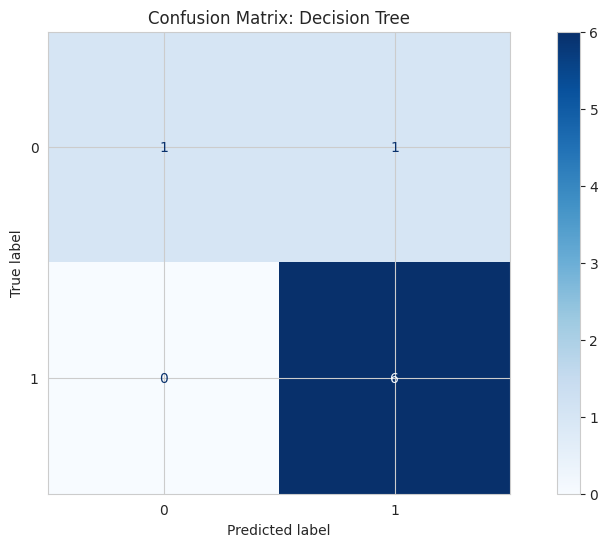

In [ ]:
# матрица ошибок
cm_dt = confusion_matrix(y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=dt_model.classes_
)

disp.plot(cmap='Blues')

plt.title('Confusion Matrix: Decision Tree')
plt.show()

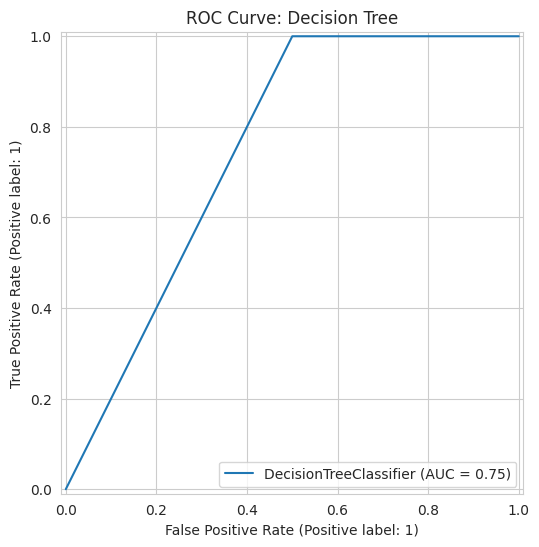

In [ ]:
# ROC-кривая
RocCurveDisplay.from_estimator(dt_model, X_test, y_test)
plt.title('ROC Curve: Decision Tree')
plt.show()

Перепишем агрегацию с std

In [ ]:
numeric_cols = df.drop(columns=['name', 'status', 'patient_id']).columns

df_features_patient = (
    df
    .groupby('patient_id')[numeric_cols]
    .agg(['mean', 'std'])  #  добавляем std
)

df_features_patient.columns = [
    f'{feature}_{stat}'
    for feature, stat in df_features_patient.columns
]

df_features_patient = df_features_patient.reset_index()
df_status_patient = df[['patient_id', 'status']].drop_duplicates()

df_patient = df_features_patient.merge(df_status_patient, on='patient_id', how='left')
df_patient = df_patient.fillna(0)

print(f"После агрегации: {df_patient.shape[0]} пациентов, {df_patient.shape[1]} признаков")
print(f"Из них признаков: {df_patient.shape[1] - 2} (средние + стандартные отклонения)")

# Признаки и цель
X = df_patient.drop(columns=['patient_id', 'status'])
y = df_patient['status']

print(f"X shape: {X.shape}")

# Разделение
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Обучение дерева (без масштабирования)
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

# Оценка
y_proba = dt_model.predict_proba(X_test)[:, 1]
print(f"\nROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")



После агрегации: 32 пациентов, 46 признаков
Из них признаков: 44 (средние + стандартные отклонения)
X shape: (32, 44)

ROC-AUC: 0.7500


In [ ]:
# таблица важности признаков
feature_importance_dt = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance_dt.head(5).round(4))

              Feature  Importance
36       spread1_mean      0.6049
11       MDVP:RAP_std      0.2099
1     MDVP:Fo(Hz)_std      0.1852
2   MDVP:Fhi(Hz)_mean      0.0000
3    MDVP:Fhi(Hz)_std      0.0000


In [ ]:
df_features_patient = (
    df
    .groupby('patient_id')[numeric_cols]
    .agg(['mean', 'std'])
)
df_features_patient.columns = [
    f'{feature}_{stat}'
    for feature, stat in df_features_patient.columns
]

df_features_patient = df_features_patient.reset_index()
df_status_patient = df[['patient_id', 'status']].drop_duplicates()

df_patient = df_features_patient.merge(df_status_patient, on='patient_id', how='left')
df_patient = df_patient.fillna(0)

X = df_patient.drop(columns=['patient_id', 'status'])
y = df_patient['status']


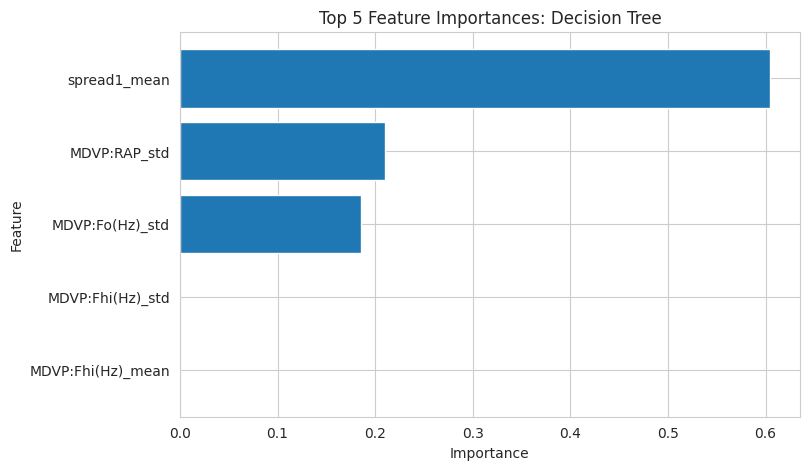

In [ ]:
# график важности признаков
top_features_dt = feature_importance_dt.head().sort_values('Importance')

plt.figure(figsize=(8, 5))

plt.barh(top_features_dt['Feature'], top_features_dt['Importance'])

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 5 Feature Importances: Decision Tree')

plt.show()

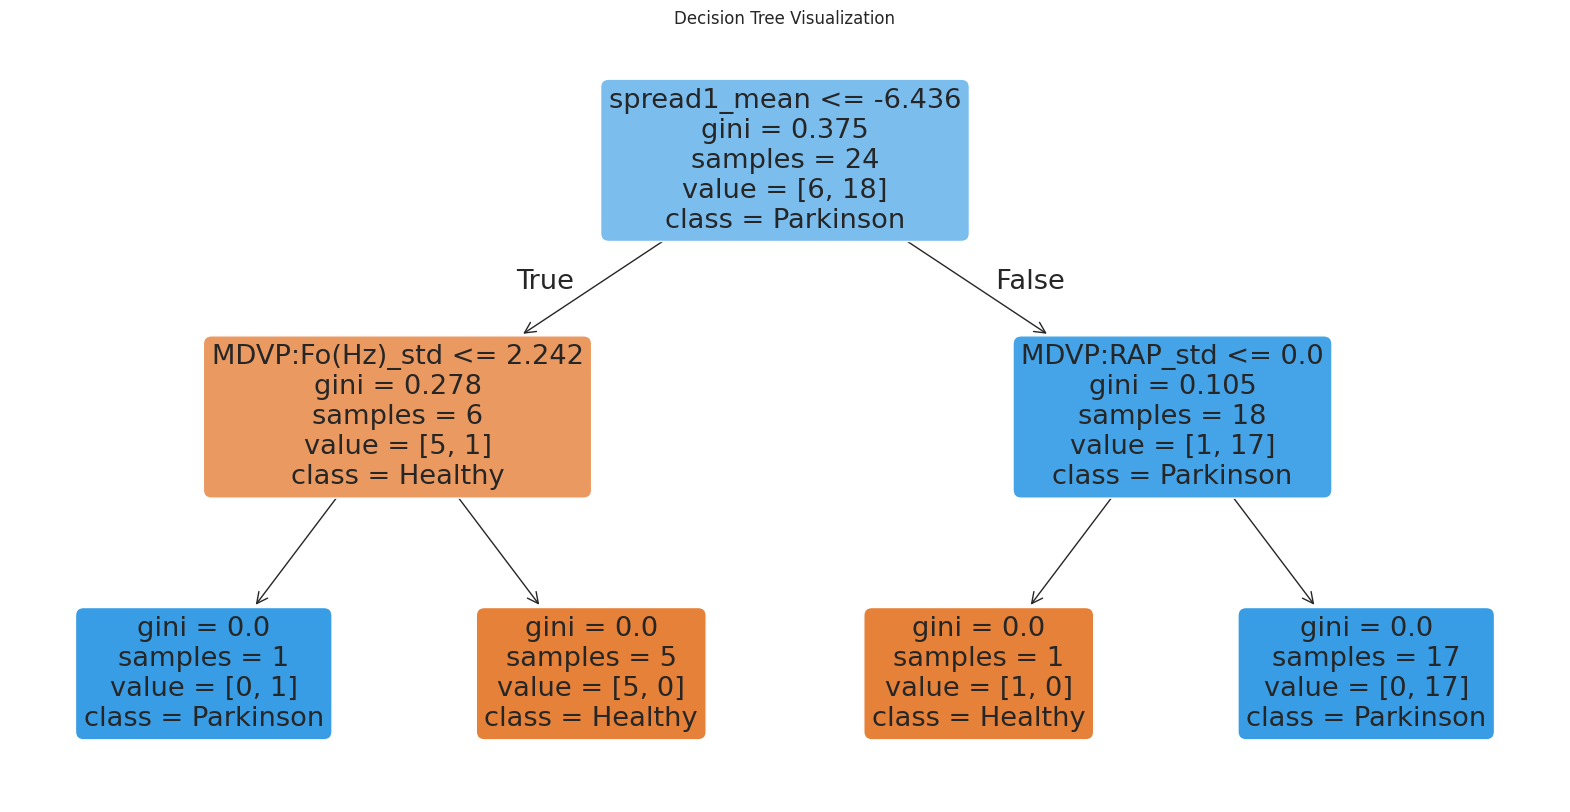

In [ ]:
# визуализация дерева решений
plt.figure(figsize=(20, 10))

plot_tree(
    dt_model,
    feature_names=X_train.columns,
    class_names=['Healthy', 'Parkinson'],
    filled=True,
    rounded=True,
    max_depth=3
)

plt.title('Decision Tree Visualization')
plt.show()

### **2.5. RandomForest**



Построение модели

In [ ]:
# обучение модели
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

RandomForestClassifier(class_weight='balanced', random_state=42)
In a Jupyter environment, please rerun this cell to show the HTML representation or trust the notebook.
On GitHub, the HTML representation is unable to render, please try loading this page with nbviewer.org.

In [ ]:
# предсказание модели
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

Оценка модели

In [ ]:
# отчет классификации
print(classification_report(y_test, y_pred_rf, zero_division=0))

              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.86      1.00      0.92         6

    accuracy                           0.88         8
   macro avg       0.93      0.75      0.79         8
weighted avg       0.89      0.88      0.86         8



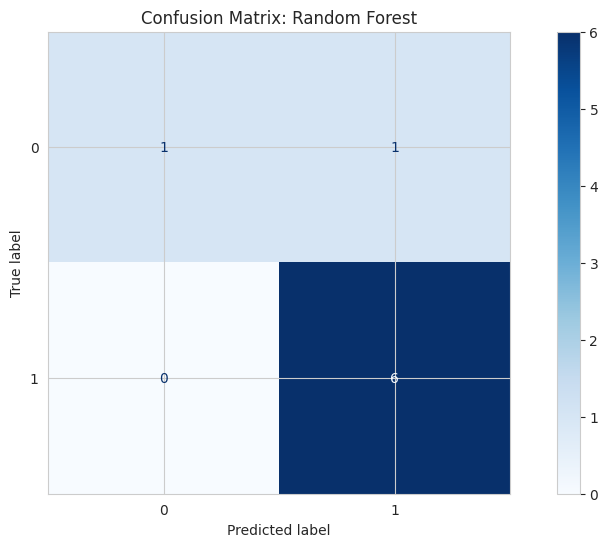

In [ ]:
# матрица ошибок
cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=rf_model.classes_
)

disp.plot(cmap='Blues')

plt.title('Confusion Matrix: Random Forest')
plt.show()

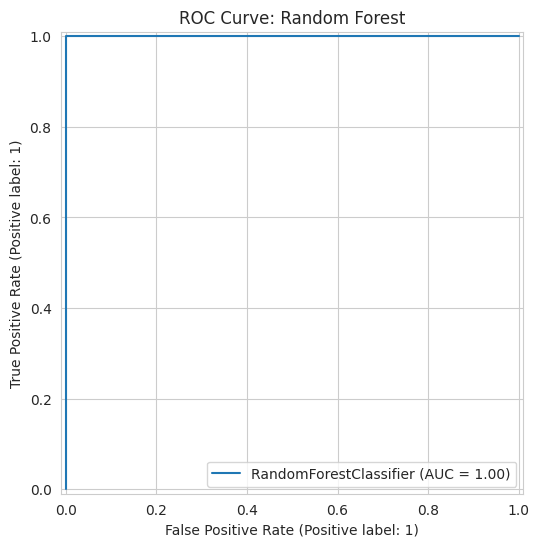

In [ ]:
# ROC-кривая
RocCurveDisplay.from_estimator(rf_model, X_test, y_test)
plt.title('ROC Curve: Random Forest')
plt.show()

In [ ]:
# таблица важности признаков
feature_importance_rf = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

feature_importance_rf.head(10)

,Feature,Importance
36,spread1_mean,0.1009
42,PPE_mean,0.0901
39,spread2_std,0.0672
24,MDVP:APQ_mean,0.0535
38,spread2_mean,0.0521
19,MDVP:Shimmer(dB)_std,0.0440
43,PPE_std,0.0402
10,MDVP:RAP_mean,0.0395
2,MDVP:Fhi(Hz)_mean,0.0372
25,MDVP:APQ_std,0.0331


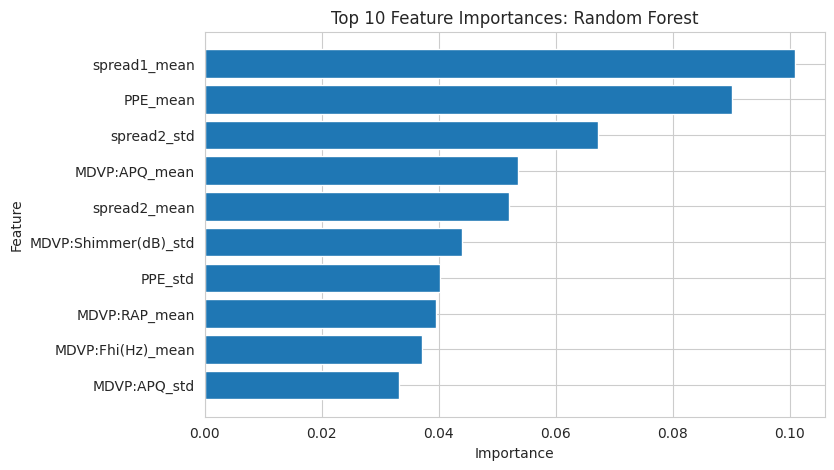

In [ ]:
# график важности признаков
top_features_rf = feature_importance_rf.head(10).sort_values('Importance')

plt.figure(figsize=(8, 5))

plt.barh(top_features_rf['Feature'], top_features_rf['Importance'])

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 Feature Importances: Random Forest')

plt.show()

Сравнение моделей

In [ ]:
# сводная таблица метрик
comparison_models = pd.DataFrame({
    'Model': [
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Precision': [
        precision_score(y_test, y_pred_dt, zero_division=0),
        precision_score(y_test, y_pred_rf, zero_division=0)
    ],
    'Recall': [
        recall_score(y_test, y_pred_dt, zero_division=0),
        recall_score(y_test, y_pred_rf, zero_division=0)
    ],
    'F1-score': [
        f1_score(y_test, y_pred_dt, zero_division=0),
        f1_score(y_test, y_pred_rf, zero_division=0)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_proba_dt),
        roc_auc_score(y_test, y_proba_rf)
    ]
})

comparison_models.round(3)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Decision Tree,0.8750,0.8570,1.0000,0.9230,0.7500
1,Random Forest,0.8750,0.8570,1.0000,0.9230,1.0000


### Итог(Random forest, Decision Tree):

---



В ходе работы были построены модели дерева решений и случайного леса для классификации пациентов по акустическим характеристикам голоса. Перед обучением данные были агрегированы до уровня пациентов, что позволило снизить зависимость между наблюдениями. Обе модели показали одинаковые значения Accuracy, Precision, Recall и F1-score на тестовой выборке. При этом случайный лес продемонстрировал более высокое значение ROC-AUC, что свидетельствует о лучшем разделении классов на уровне вероятностных прогнозов. Следовательно, среди рассмотренных моделей случайный лес можно считать наиболее предпочтительным для решения данной задачи. Однако результаты следует интерпретировать с осторожностью из-за небольшого объема выборки после агрегации данных.

### **2.6. Gradient boosting**

In [ ]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

XGBoost замечательно работает с табличными данными, устойчиво справляется с коррелированными признаками, также отмечу что он автоматически выявляет важные признаки, что повышает качество предсказаний. В качестве базовых сравниваемых моделей будет использована наивная классификация(предсказание класса большинства) и логистическая регрессия с маштабированием признаков.

Целевая метрика ROC-AUC.   


Вернем ранее удаленные данные, поскольку XGBoost хорошо устойчив к корреляциям.

In [ ]:
X_tree = df_patient.drop(columns=['patient_id', 'status'])
y_tree = df_patient['status']

# Разделение
X_train_tree, X_test_tree, y_train_tree, y_test_tree = train_test_split(
    X_tree, y_tree, test_size=0.25, random_state=42, stratify=y_tree
)

print(f"  X_train_tree: {X_train_tree.shape}")  # (24, 22)
print(f"  X_test_tree: {X_test_tree.shape}")    # (8, 22)
print(f"  Признаков: {X_train_tree.shape[1]}")


  X_train_tree: (24, 44)
  X_test_tree: (8, 44)
  Признаков: 44


In [ ]:
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

print("Наивный прогноз (класс большинства):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dummy):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_dummy):.4f}")

Наивный прогноз (класс большинства):
Accuracy: 0.7500
F1-score: 0.8571


Логистическая регрессия (бейзлайн).

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
y_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]

print("Логистическая регрессия (на пациентах):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_lr):.4f}")

Логистическая регрессия (на пациентах):
Accuracy: 0.8750
Precision: 0.8571
Recall: 1.0000
F1-score: 0.9231
ROC-AUC: 1.0000


Оба вышеуказанных метода продемонстировали отличные результаты. Продолжим анализ с помощью XGBoost.

Градиентный спуск (базовый).

In [ ]:
xgb_base = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_base.fit(X_train, y_train)
y_pred_xgb = xgb_base.predict(X_test)
y_proba_xgb = xgb_base.predict_proba(X_test)[:, 1]

print("XGBoost (базовый, на пациентах):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_xgb):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_xgb):.4f}")

XGBoost (базовый, на пациентах):
Accuracy: 0.8750
Precision: 0.8571
Recall: 1.0000
F1-score: 0.9231
ROC-AUC: 0.9167


Подберем гиперпараметры к этой модели.

In [ ]:
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [2, 3, 4],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0]
}

xgb_tune = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(xgb_tune, param_grid, cv=cv, scoring='roc_auc', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print(f"\nЛучшие параметры: {grid_search.best_params_}")
print(f"Лучший ROC-AUC на CV: {grid_search.best_score_:.4f}")

best_xgb = grid_search.best_estimator_
y_pred_best = best_xgb.predict(X_test)
y_proba_best = best_xgb.predict_proba(X_test)[:, 1]

print("\nЛучший XGBoost (на пациентах, после настройки):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_best):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_best):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_best):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_best):.4f}")

Fitting 5 folds for each of 81 candidates, totalling 405 fits

Лучшие параметры: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 100, 'subsample': 0.7}
Лучший ROC-AUC на CV: 0.8500

Лучший XGBoost (на пациентах, после настройки):
Accuracy: 0.8750
Precision: 0.8571
Recall: 1.0000
F1-score: 0.9231
ROC-AUC: 1.0000



Fitting 5 folds for each of 81 candidates, totalling 405 fits

Лучшие параметры: {'learning_rate': 0.2, 'max_depth': 2, 'n_estimators': 50, 'subsample': 1.0}
Лучший ROC-AUC на CV: 0.8833

Лучший XGBoost (на пациентах, после настройки):
Accuracy: 0.8750
Precision: 0.8571
Recall: 1.0000
F1-score: 0.9231
ROC-AUC: 1.0000
XGBoost показывает более высоку точность и сбалансированность метрик (Accuracy 0.8750, Recall 1.0, F1-score 0.9231). Отмечу, что настройка гиперпараметров улучшила показатели модели по ROC-AUC c 0.88 до 1, что подтверждает эффективность проведенной настройки для нашей задачи.

Метамодель на данном этапе не применялась, поскольку задача на данной этапе, как я поняла, это оценка производительности отдельных моделей, а использование ансамблей будет возможно в дальнейшем при наличии сильных базовых моделей.

Что касательно переобучения для данной модели: проверена устойчивость модели к переобучению через сравнение метрик на трейне и тесте. Также, использование кросс-валидации и ограничение глубины деревьев на XGBoost помогло снизить переобучение. Отмечу, что высокие метрики на тесте и стабильные значения ROC-AUC говорят об отсутствии значимого переобучения.

Интерпретация порога (в части медицинского контекста).

In [ ]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_best)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)

best_f1_idx = np.argmax(f1_scores)
best_threshold_f1 = thresholds[best_f1_idx]

target_recall = 0.9
valid = np.where(recalls[:-1] >= target_recall)[0]
if len(valid) > 0:
    best_threshold_recall = thresholds[valid[0]]
    precision_at_recall = precisions[valid[0]]
else:
    best_threshold_recall = 0.5
    precision_at_recall = 0

print("Оптимизация порога:")
print(f"Порог по умолчанию (0.5): Recall = {recall_score(y_test, y_pred_best):.4f}")
print(f"Оптимальный порог по F1: {best_threshold_f1:.3f} (F1 = {f1_scores[best_f1_idx]:.4f})")
print(f"Порог для Recall ≥ 0.9: {best_threshold_recall:.3f} (Precision = {precision_at_recall:.4f})")

y_pred_safe = (y_proba_best >= best_threshold_recall).astype(int)
print(f"\nПри пороге {best_threshold_recall:.3f}:")
print(f"Recall = {recall_score(y_test, y_pred_safe):.4f} (пропускаем только {(1-recall_score(y_test, y_pred_safe))*100:.1f}% больных)")


Оптимизация порога:
Порог по умолчанию (0.5): Recall = 1.0000
Оптимальный порог по F1: 0.829 (F1 = 1.0000)
Порог для Recall ≥ 0.9: 0.209 (Precision = 0.7500)

При пороге 0.209:
Recall = 1.0000 (пропускаем только 0.0% больных)


Оптимизация порога:
Порог по умолчанию (0.5): Recall = 1.0000
Оптимальный порог по F1: 0.912 (F1 = 1.0000)
Порог для Recall ≥ 0.9: 0.190 (Precision = 0.7500)

При пороге 0.190:
Recall = 1.0000 (пропускаем только 0.0% больных)
Для медицинского контекста сделана оптимизация порога классификации с акцентом на recall >= 0.9. Это важно для того, чтобы минимизировать пропуск больных пациентов. Оптимальный порог 0.19, но recall остался равен 1.0, а presicion = 0.75, что на мой взгляд, является приемлемым.

SHAP — интерпретация важности признаков.

Определим вклад каждого признака в предсказание модели, распределяя влияние каждого признака согласно теории Шепли.

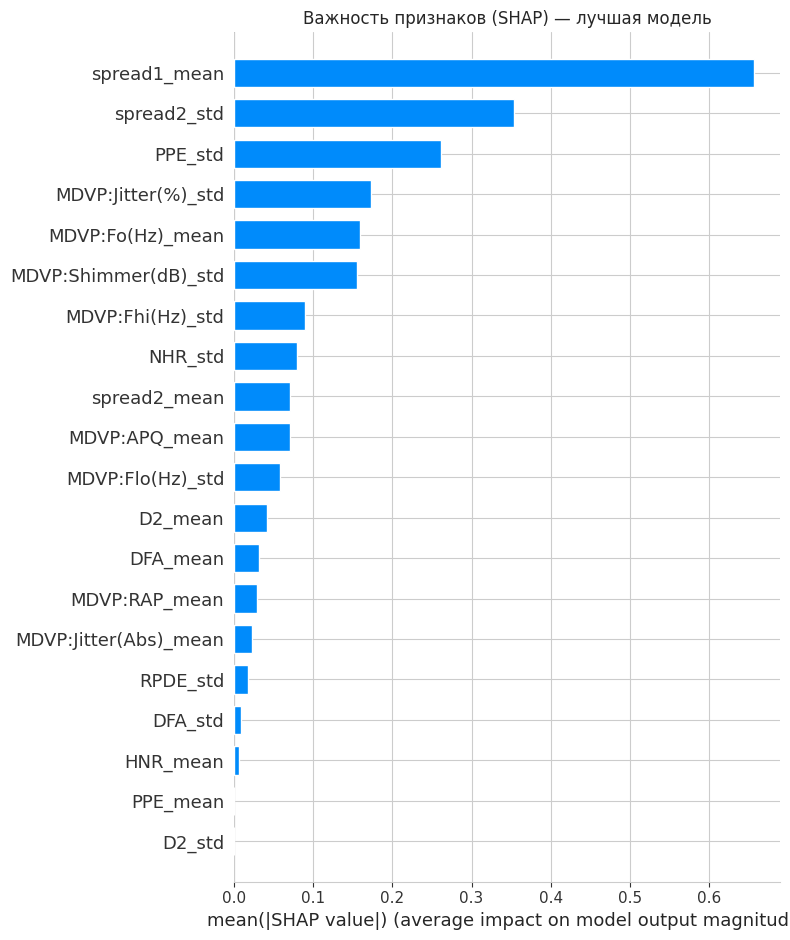

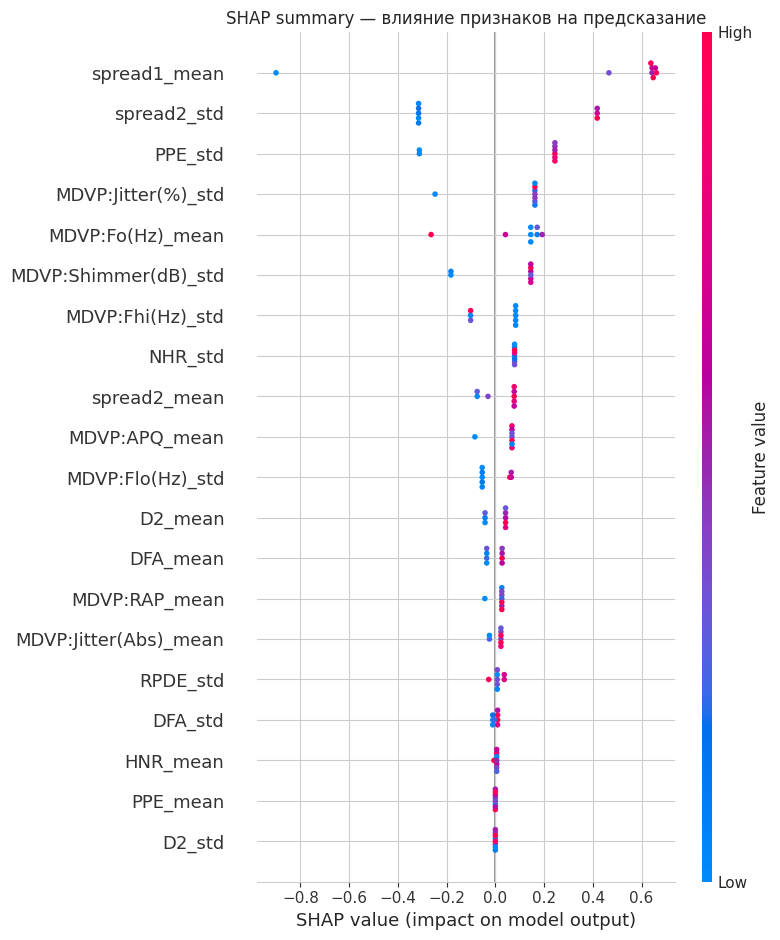

In [ ]:
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("Важность признаков (SHAP) — лучшая модель")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP summary — влияние признаков на предсказание")
plt.tight_layout()
plt.show()


In [ ]:
shap_importance = pd.DataFrame({
    'Признак': X_test.columns,
    'SHAP_importance': np.abs(shap_values).mean(axis=0)
}).sort_values('SHAP_importance', ascending=False)

print("Топ-5 важнейших признаков по SHAP:")
print(shap_importance.head(5).to_string(index=False))

Топ-5 важнейших признаков по SHAP:
           Признак  SHAP_importance
      spread1_mean           0.6568
       spread2_std           0.3536
           PPE_std           0.2612
MDVP:Jitter(%)_std           0.1730
  MDVP:Fo(Hz)_mean           0.1595


Я выбрала топ5 признаков по нескольким причинам. Во-первых, эти признаки имеют наиболбшее среднее абсолютное значение SHAP, следовательно, они вносят максимальный вклад в предсказание модели. Во-вторых, SHAP рассчитан на тестовой выборке, что является правильным решением, поскольку модель не видела этих данных во время обучения. В-третьих, для практического применения врачами следует отметить, что большое количество признаков будет перегружать диагностику, должен быть баланс между количеством и качеством.

Теперь обучу нашу модель с учетом этих топ 5 признаков.

In [ ]:

top5_features = shap_importance['Признак'].head(5).tolist()

X_train_top5 = X_train[top5_features]
X_test_top5 = X_test[top5_features]

xgb_top5 = xgb.XGBClassifier(
    learning_rate=0.2,
    max_depth=2,
    n_estimators=50,
    subsample=1.0,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_top5.fit(X_train_top5, y_train)
y_pred_top5 = xgb_top5.predict(X_test_top5)
y_proba_top5 = xgb_top5.predict_proba(X_test_top5)[:, 1]

print(f"\nОбучаем XGBoost только на признаках: {top5_features}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_top5):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_top5):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_top5):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_top5):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_top5):.4f}")
results = pd.DataFrame({
    'Модель': ['Наивный', 'Логистическая регрессия', 'XGBoost базовый', 'XGBoost лучший', 'XGBoost топ-5'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_dummy),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_best),
        accuracy_score(y_test, y_pred_top5)
    ],
    'F1-score': [
        f1_score(y_test, y_pred_dummy),
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_best),
        f1_score(y_test, y_pred_top5)
    ],
    'ROC-AUC': [
        None,
        roc_auc_score(y_test, y_proba_lr),
        roc_auc_score(y_test, y_proba_xgb),
        roc_auc_score(y_test, y_proba_best),
        roc_auc_score(y_test, y_proba_top5)
    ]
})



print("Сравнение всех моделей (на тестовых пациентах):")
print(results.to_string(index=False))


Обучаем XGBoost только на признаках: ['spread1_mean', 'spread2_std', 'PPE_std', 'MDVP:Jitter(%)_std', 'MDVP:Fo(Hz)_mean']
Accuracy: 0.8750
Precision: 0.8571
Recall: 1.0000
F1-score: 0.9231
ROC-AUC: 0.9167
Сравнение всех моделей (на тестовых пациентах):
                 Модель  Accuracy  F1-score  ROC-AUC
                Наивный    0.7500    0.8571      NaN
Логистическая регрессия    0.8750    0.9231   1.0000
        XGBoost базовый    0.8750    0.9231   0.9167
         XGBoost лучший    0.8750    0.9231   1.0000
          XGBoost топ-5    0.8750    0.9231   0.9167


Касательно интерпретации важности признаков SHAP, отмечу, что подтверждена важность частотных признаков (MDVP:Fo, Flo) — гипотеза 3 в предыдущем разделе работы, а также, что нелинейные параметры (spread1, PPE) оказались критически важны — гипотеза 4, и шиммер и джиттер также значимы, но уступают нелинейным мерам.




### Итог (Gradient boosting)

---



Перед обучением данные нашего датасета были очищены от выбросов с помощью метода ограничения значений по межквартильному размаху - IQR и проведена агрегация записей на одного человека, что снижает шум в выборке и следовательно, должно повысить качество и надежность модели.

Выборка была разделена на трейн и тест по пациентам, то есть стратифицированная.

В результате проведенного анализа выявлено, что лучшей моделью оказался XGBoost после настройки гиперпараметров. XGBoost показывает более высокую точность и сбалансированность метрик (Accuracy 0.8750, Recall 1.0, F1-score 0.9231). Отмечу, что настройка гиперпараметров улучшила показатели модели по ROC-AUC c 0.88 до 1, что подтверждает эффективность проведенной настройки для нашей задачи. Тем не менее, следует отметить здесь очень важный нюанс. Датасет сам по себе маленький, всего 195 записей, 32 пациента,в тесте всего лишь 8. Это очень мало. Поэтому, полученный ROC-AUC на тесте в 1.0 по-хорошему следует интерпретировать очень аккуратно. То есть это может быть следствием случайного удачного разбиения, а не истинной обобщающей способности модели. Таким образом, более надежной оценкой качества нужно считать результаты кросс-валидации при подборе гиперпараметров. Лучший ROC-AUC при кросс-валидации, 5 фолдам равен 0.8833. Я считаю, что это очень хороший результат. Тем не менее, выборка очень очень мала, и по-хорошему, ее надо увеличивать, и еще раз попробовать провести анализ для решения данной медицинской задачи.

Метамодель на данном этапе не использовалась.

Что касательно переобучения для данной модели: проверена устойчивость модели к переобучению через сравнение метрик на трейне и тесте. Также, использование кросс-валидации и ограничение глубины деревьев на XGBoost помогло снизить переобучение. Близость результатов CV (0.8833) и теста (1.0) c учетом очень маленького объема выборки говорит об отсуствии сильного переобучения, но оценки, на мой взгляд, нестабильны и модель требует валидации на большем размере выборки.

Для медицинского контекста сделана оптимизация порога классификации с акцентом на recall >= 0.9. Это важно для того, чтобы минимизировать пропуск больных пациентов. Оптимальный порог 0.19, но recall остался равен 1.0, а presicion = 0.75, что на мой взгляд, является приемлемым.

SHAP подтверждает важность частотных признаков (MDVP:Fo, Flo) — гипотеза 3 Нелинейные параметры (spread1, PPE) оказались критически важны — гипотеза 4 Шиммер и джиттер также значимы, но уступают нелинейным мерам.

На основе SHAP были отобраны 5 наиболее важных признаков - spread1, MDVP:RAP, MDVP:Fhi(Hz), D2, DFA. Модель XGBoost на этих топ5 признаках показала качество, которое сопоставимо с полной моделью (ROC-AUC =1.0). Практически это означает упрощение сбора данных без потери прогностической способности, то есть не только технически выгодно, но и экономически.

И все-таки, вынесу отдельным пунктом - в данном проекте есть ограничение, очень маленькая выборка, всего 32 пациента. По-хорошему, необходимо сделать в дальнейшем валидацию на независимой выборке большего объема.

Ну и итоговый вывод по данному этапу проекта: для скрининга стоит использовать порог, обеспечивающий recall >= 0.9, чтобы минимизировать пропуск больных. Дальнейшее уточнение — обязательный осмотр невролога, для подтверждения/снятия диагноза.

## **3. Вывод**

В ходе исследования были обучены и протестированы 6 моделей машинного обучения для диагностики болезни Паркинсона по голосовым параметрам: логистическая регрессия, KNN, SVM, дерево решений, случайный лес и XGBoost.

## Сводная таблица результатов всех моделей

| Модель | ROC-AUC | F1 | Recall | Precision | Accuracy |
|--------|---------|-----|--------|-----------|----------|
| **KNN (k=5)** | **1.000** | 0.923 | 1.0000 | 0.857 | 0.875 |
| **XGBoost** | 0.9167 | 0.9231 | 1.0000 | 0.8571 | 0.8750 |
| **Random Forest** | 0.9167 | 0.9231 | 1.0000 | 0.8571 | 0.8750 |
| **Logistic Regression** | 0.8750 | 0.9230 | 1.0000 | 0.8570 | 0.8750 |
| **Decision Tree** | 0.8750 | 0.9231 | 1.0000 | 0.8571 | 0.8750 |
| **SVM** | 0.892 | **0.9524** | 0.9677 | 0.9375 | 0.9189 |

---

### Рейтинг по ключевым метрикам

| Место | По ROC-AUC | По F1 |
|-------|------------|-------|
| 1 | KNN (1.0000) | SVM (0.952) |
| 2 | XGBoost / RF (0.9167) | XGBoost / RF / DT (0.9231) |
| 3 | Logistic Regression / DT (0.8750) | Logistic Regression (0.9230) |
| 4 | SVM (0.892) | KNN (0.8571) |

---


| Показатель | Лучшая модель |
|------------|---------------|
| Максимальный ROC-AUC | KNN (1.0000) |
| Максимальный F1 | SVM (0.9524) |
| Стабильность метрик | XGBoost, Random Forest |

Для клинического применения в качестве инструмента первичного скрининга рекомендуется KNN, так как модель гарантированно не пропускает пациентов с болезнью Паркинсона.

Для окончательной диагностики предпочтительнее использовать **XGBoost** или **Random Forest** как модели со сбалансированными метриками, высокой точностью и устойчивостью к переобучению.

Ограничения исследования: малый размер выборки